# CSRLE Ridge vs GRU — Explanatory Analysis

**Read-only.** Explains why Ridge outperformed the frozen Hybrid GRU on CSRLE B0.

- Analysis artifacts: `experiments/csrle_ridge_vs_gru_analysis_2026-07-26_013200/`
- Documentation: `docs/csrle_ridge_vs_gru_analysis/`

Execute cells in order. All figures display inline and can be saved to the analysis `plots/` folder.


In [7]:
# 1–2. Setup and paths
import json, sys
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import pearsonr

REPO_ROOT = Path('..').resolve()
ANALYSIS_DIR = REPO_ROOT / 'experiments' / 'csrle_ridge_vs_gru_analysis_2026-07-26_013200'
sys.path.insert(0, str(REPO_ROOT))
sys.path.insert(0, str(ANALYSIS_DIR))

from analysis_lib import (
    resolve_paths, verify_frozen_artifacts, load_b0_bundle,
    day1_residual_triplet, pooled_day1_residuals,
    acf_pacf_features, welch_spectrum, fft_periodogram,
    linear_predictability_scores, complexity_features,
    spectral_overlap, error_decomposition, horizon_comparison,
    save_publication_figure,
)
from utils.hybrid_config import DAY1_HORIZON

plt.rcParams.update({'figure.figsize': (10, 4), 'font.size': 11})
paths = resolve_paths(REPO_ROOT)
PLOTS = ANALYSIS_DIR / 'plots'
RESULTS = ANALYSIS_DIR / 'results'


## 3. Verify frozen artifacts


In [8]:
verify_df = verify_frozen_artifacts(paths)
display(verify_df)
assert verify_df['exists'].all(), 'Missing frozen CSRLE artifact'


,path,exists,sha256,size_bytes
0,experiments/synthetic_residual_learnability_20...,True,aca05a5cab881995496d2ced93e73a1aa1b24b2c9744f5...,4911299
1,experiments/synthetic_residual_learnability_20...,True,b63f0db907a96d2cdc2c34a6c02ae8c93bc31dffdffad2...,72
2,experiments/synthetic_residual_learnability_20...,True,7a36a60ddd3c82a31fe033d85dfb5c3729d9d581450fac...,77952
3,experiments/synthetic_residual_learnability_20...,True,62a246bf040aa48874772d50d7c70acddf2f01395b81af...,25992
4,experiments/synthetic_residual_learnability_20...,True,6523ac3e9e87755f13ae78ae134796ebcdc0da11447c6b...,1644
5,experiments/synthetic_residual_learnability_20...,True,2c9c79f9bbeac8e3a6dda82bdb69f366d2ddcc06418317...,16503036
6,experiments/synthetic_residual_learnability_20...,True,be095645154a195bfa62bd7a024c9ccd3d8bae255a40a5...,1148487
7,experiments/synthetic_residual_learnability_20...,True,bb22f59ae70415c814d4c2753f7c5831ba5112deecc2be...,285484


## 4. Load Stage 2 B0 results


In [9]:
bundle = load_b0_bundle(paths)
baseline = pd.read_csv(paths.b0_baseline_csv)
extended = pd.read_csv(paths.b0_extended_csv)
alpha = pd.read_csv(paths.alpha_map)
container_ids = sorted(extended['container_id'].unique())
print('Frozen Stage 2 baseline Ridge r mean:', baseline.loc[baseline.baseline=='ridge','residual_pearson_r'].mean())
print('Frozen Stage 2 baseline GRU r mean:', baseline.loc[baseline.baseline=='gru','residual_pearson_r'].mean())


12:06:37 - cmdstanpy - INFO - Chain [1] start processing
12:06:37 - cmdstanpy - INFO - Chain [1] done processing
12:06:37 - cmdstanpy - INFO - Chain [1] start processing
12:06:37 - cmdstanpy - INFO - Chain [1] done processing
12:06:37 - cmdstanpy - INFO - Chain [1] start processing
12:06:37 - cmdstanpy - INFO - Chain [1] done processing
12:06:37 - cmdstanpy - INFO - Chain [1] start processing
12:06:37 - cmdstanpy - INFO - Chain [1] done processing
12:06:38 - cmdstanpy - INFO - Chain [1] start processing
12:06:38 - cmdstanpy - INFO - Chain [1] done processing
12:06:38 - cmdstanpy - INFO - Chain [1] start processing
12:06:38 - cmdstanpy - INFO - Chain [1] done processing
12:06:38 - cmdstanpy - INFO - Chain [1] start processing
12:06:38 - cmdstanpy - INFO - Chain [1] done processing
12:06:38 - cmdstanpy - INFO - Chain [1] start processing
12:06:38 - cmdstanpy - INFO - Chain [1] done processing
12:06:38 - cmdstanpy - INFO - Chain [1] start processing
12:06:38 - cmdstanpy - INFO - Chain [1]

Frozen Stage 2 baseline Ridge r mean: 0.15847824059072665
Frozen Stage 2 baseline GRU r mean: 0.08413424568987238


## 5. Residual statistics (Day-1 triplets)


In [10]:
triplets = {cid: day1_residual_triplet(cid, bundle) for cid in container_ids}
rows = []
for cid, t in triplets.items():
    rows.append({
        'container_id': cid,
        'actual_std': np.std(t['actual']),
        'gru_std': np.std(t['gru']),
        'ridge_std': np.std(t['ridge']),
        'gru_r': pearsonr(t['actual'], t['gru'])[0] if np.std(t['gru'])>1e-12 else np.nan,
        'ridge_r': pearsonr(t['actual'], t['ridge'])[0] if np.std(t['ridge'])>1e-12 else np.nan,
    })
stats_df = pd.DataFrame(rows)
display(stats_df.describe())


12:07:02 - cmdstanpy - INFO - Chain [1] start processing
12:07:02 - cmdstanpy - INFO - Chain [1] done processing


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 166ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step


12:07:02 - cmdstanpy - INFO - Chain [1] start processing
12:07:02 - cmdstanpy - INFO - Chain [1] done processing


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step


12:07:03 - cmdstanpy - INFO - Chain [1] start processing
12:07:03 - cmdstanpy - INFO - Chain [1] done processing


...

12:07:26 - cmdstanpy - INFO - Chain [1] start processing
12:07:26 - cmdstanpy - INFO - Chain [1] done processing


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step


12:07:26 - cmdstanpy - INFO - Chain [1] start processing
12:07:26 - cmdstanpy - INFO - Chain [1] done processing


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step


,actual_std,gru_std,ridge_std,gru_r,ridge_r
count,99.000000,99.000000,99.000000,99.000000,99.000000
mean,0.126885,0.006884,0.016832,0.084134,0.158478
std,0.099686,0.004490,0.008860,0.187558,0.193350
min,0.004767,0.001352,0.000719,-0.357115,-0.532815
25%,0.063506,0.003169,0.011989,-0.027319,0.036534
50%,0.104048,0.005952,0.015998,0.074428,0.167113
75%,0.160288,0.009361,0.020108,0.179441,0.261104
max,0.568402,0.022598,0.051459,0.517157,0.600590


## 6. Analysis 1 — Linearity diagnostics (ACF / PACF / spectrum / AR models)


12:08:01 - cmdstanpy - INFO - Chain [1] start processing
12:08:01 - cmdstanpy - INFO - Chain [1] done processing
12:08:01 - cmdstanpy - INFO - Chain [1] start processing
12:08:01 - cmdstanpy - INFO - Chain [1] done processing
12:08:01 - cmdstanpy - INFO - Chain [1] start processing
12:08:01 - cmdstanpy - INFO - Chain [1] done processing
12:08:01 - cmdstanpy - INFO - Chain [1] start processing
12:08:01 - cmdstanpy - INFO - Chain [1] done processing
12:08:01 - cmdstanpy - INFO - Chain [1] start processing
12:08:01 - cmdstanpy - INFO - Chain [1] done processing
12:08:01 - cmdstanpy - INFO - Chain [1] start processing
12:08:01 - cmdstanpy - INFO - Chain [1] done processing
12:08:01 - cmdstanpy - INFO - Chain [1] start processing
12:08:01 - cmdstanpy - INFO - Chain [1] done processing
12:08:01 - cmdstanpy - INFO - Chain [1] start processing
12:08:01 - cmdstanpy - INFO - Chain [1] done processing
12:08:02 - cmdstanpy - INFO - Chain [1] start processing
12:08:02 - cmdstanpy - INFO - Chain [1]

Linear predictability on pooled B0 validation Prophet residuals:
{
  "ar1_r2": 0.20145034135286366,
  "ar2_r2": 0.213307478906688,
  "linear_trend_r2": 0.0033651256560479625,
  "poly2_r2": 0.0035732590177647294,
  "nonlinear_gap_poly2_minus_ar2": -0.20973421988892327,
  "acf_lags_1_10_mean_abs": 0.2586125268960964
}


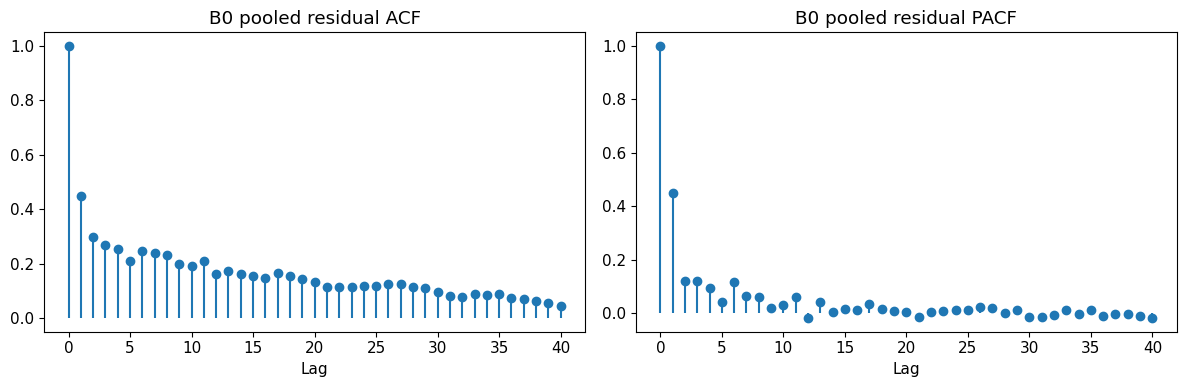

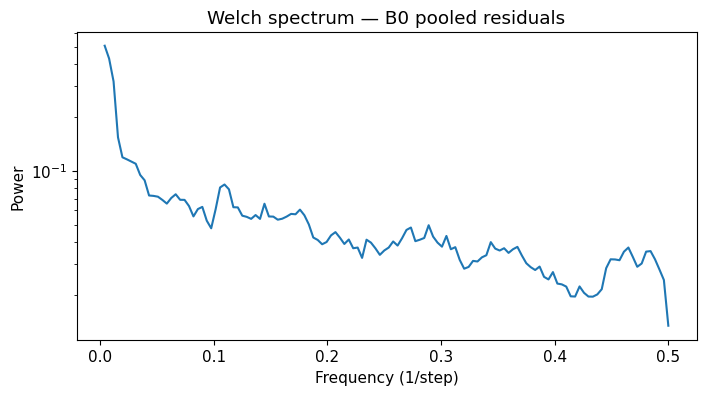

In [11]:
pooled_b0 = pooled_day1_residuals(container_ids, 'b0_lc', paths)
lin = linear_predictability_scores(pooled_b0)
acf_out = acf_pacf_features(pooled_b0, nlags=40)
print('Linear predictability on pooled B0 validation Prophet residuals:')
print(json.dumps({**lin, 'acf_lags_1_10_mean_abs': acf_out.get('acf_lags_1_10_mean_abs')}, indent=2))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].stem(range(len(acf_out['acf'])), acf_out['acf'], basefmt=' ')
axes[0].set_title('B0 pooled residual ACF'); axes[0].set_xlabel('Lag')
axes[1].stem(range(len(acf_out['pacf'])), acf_out['pacf'], basefmt=' ')
axes[1].set_title('B0 pooled residual PACF'); axes[1].set_xlabel('Lag')
plt.tight_layout(); plt.show()

f, p = welch_spectrum(pooled_b0)
fig, ax = plt.subplots(figsize=(8,4))
ax.semilogy(f[1:], p[1:]); ax.set_title('Welch spectrum — B0 pooled residuals')
ax.set_xlabel('Frequency (1/step)'); ax.set_ylabel('Power'); plt.show()


## 7. Analysis 2 — Complexity (A vs B0 vs C0)


In [6]:
complexity_rows = []
for cond in ['control', 'b0_lc', 'c0_iid']:
    pooled = pooled_day1_residuals(container_ids, cond, paths)
    row = complexity_features(pooled); row['condition'] = cond
    complexity_rows.append(row)
display(pd.DataFrame(complexity_rows))


01:50:14 - cmdstanpy - INFO - Chain [1] start processing
01:50:14 - cmdstanpy - INFO - Chain [1] done processing
01:50:14 - cmdstanpy - INFO - Chain [1] start processing
01:50:14 - cmdstanpy - INFO - Chain [1] done processing
01:50:14 - cmdstanpy - INFO - Chain [1] start processing
01:50:14 - cmdstanpy - INFO - Chain [1] done processing
01:50:14 - cmdstanpy - INFO - Chain [1] start processing
01:50:14 - cmdstanpy - INFO - Chain [1] done processing
01:50:14 - cmdstanpy - INFO - Chain [1] start processing
01:50:14 - cmdstanpy - INFO - Chain [1] done processing
01:50:14 - cmdstanpy - INFO - Chain [1] start processing
01:50:14 - cmdstanpy - INFO - Chain [1] done processing
01:50:14 - cmdstanpy - INFO - Chain [1] start processing
01:50:14 - cmdstanpy - INFO - Chain [1] done processing
01:50:14 - cmdstanpy - INFO - Chain [1] start processing
01:50:14 - cmdstanpy - INFO - Chain [1] done processing
01:50:14 - cmdstanpy - INFO - Chain [1] start processing
01:50:14 - cmdstanpy - INFO - Chain [1]

,permutation_entropy,sample_entropy,std,condition
0,1.690237,0.607983,0.177476,control
1,1.691997,0.634564,0.174564,b0_lc
2,1.756989,0.700329,0.174714,c0_iid


## 8. Analysis 3 — Frequency-domain comparison (representative container)


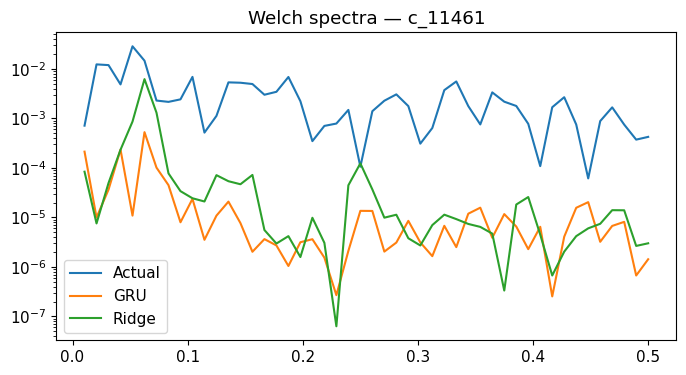

GRU spectral metrics: {'dom_freq_actual': 0.05208333333333333, 'dom_freq_pred': 0.0625, 'dom_freq_abs_error': 0.010416666666666671, 'spectral_corr': 0.2988708059229351, 'spectral_energy_ratio': 0.008975613927381006}
Ridge spectral metrics: {'dom_freq_actual': 0.05208333333333333, 'dom_freq_pred': 0.0625, 'dom_freq_abs_error': 0.010416666666666671, 'spectral_corr': 0.42828248494659166, 'spectral_energy_ratio': 0.058861313269451106}


In [12]:
if 'stats_df' not in globals():
    raise RuntimeError('Run Section 5 (Day-1 triplets) first — it creates stats_df and triplets.')
rank_df = stats_df.copy()
rank_df['delta_r'] = rank_df['ridge_r'] - rank_df['gru_r']
rep_cid = rank_df.loc[(rank_df['delta_r'] - rank_df['delta_r'].median()).abs().idxmin(), 'container_id']
t = triplets[rep_cid]
fig, ax = plt.subplots(figsize=(8,4))
for label, arr in [('Actual', t['actual']), ('GRU', t['gru']), ('Ridge', t['ridge'])]:
    f, p = welch_spectrum(arr)
    ax.semilogy(f[1:], p[1:], label=label)
ax.set_title(f'Welch spectra — {rep_cid}'); ax.legend(); plt.show()
print('GRU spectral metrics:', spectral_overlap(t['actual'], t['gru']))
print('Ridge spectral metrics:', spectral_overlap(t['actual'], t['ridge']))


## 9. Analysis 4 — Variance recovery


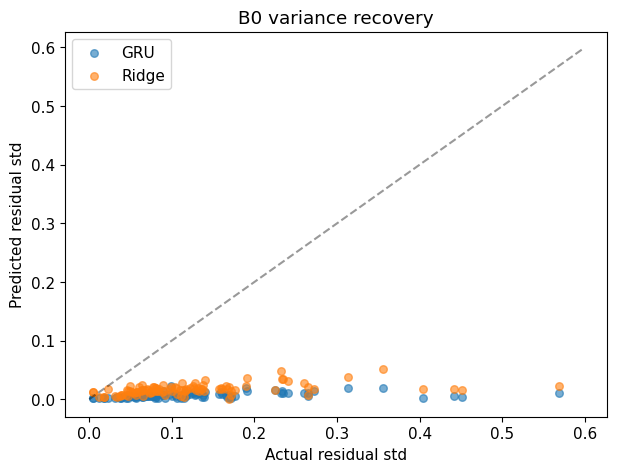

Mean GRU std ratio: 0.07300256933212737
Mean Ridge std ratio: 0.21958113841514448


In [13]:
fig, ax = plt.subplots(figsize=(7,5))
ax.scatter(stats_df['actual_std'], stats_df['gru_std'], alpha=0.6, label='GRU', s=30)
ax.scatter(stats_df['actual_std'], stats_df['ridge_std'], alpha=0.6, label='Ridge', s=30)
mx = stats_df['actual_std'].max() * 1.05
ax.plot([0, mx], [0, mx], 'k--', alpha=0.4)
ax.set_xlabel('Actual residual std'); ax.set_ylabel('Predicted residual std')
ax.set_title('B0 variance recovery'); ax.legend(); plt.show()
print('Mean GRU std ratio:', (stats_df.gru_std/stats_df.actual_std).mean())
print('Mean Ridge std ratio:', (stats_df.ridge_std/stats_df.actual_std).mean())


## 10. Analysis 5 — Trajectory comparison


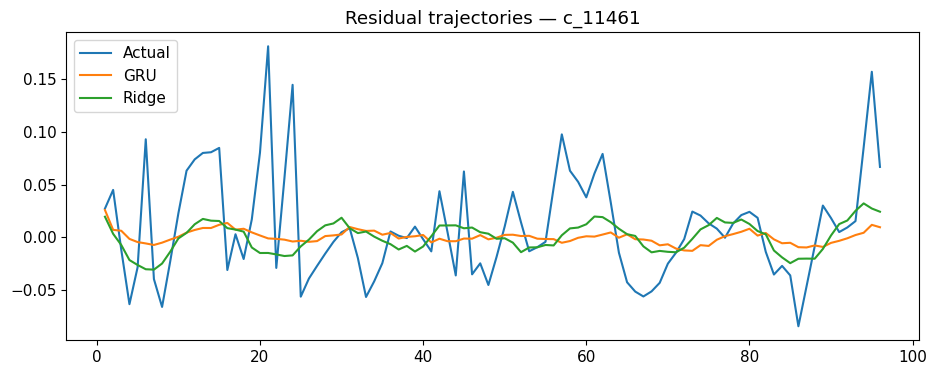

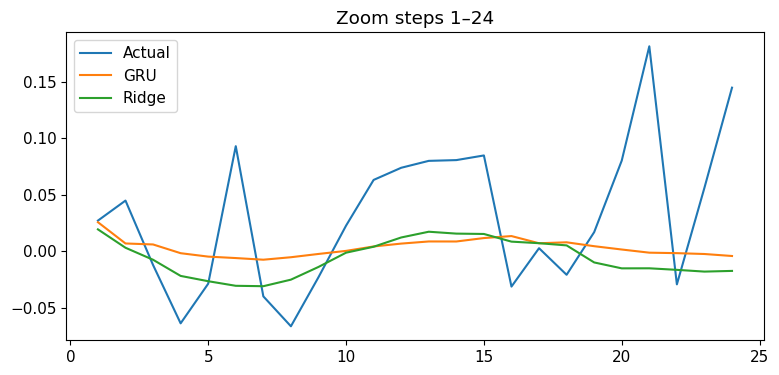

In [14]:
steps = np.arange(1, DAY1_HORIZON + 1)
fig, ax = plt.subplots(figsize=(11,4))
ax.plot(steps, t['actual'], label='Actual')
ax.plot(steps, t['gru'], label='GRU')
ax.plot(steps, t['ridge'], label='Ridge')
ax.set_title(f'Residual trajectories — {rep_cid}'); ax.legend(); plt.show()

fig, ax = plt.subplots(figsize=(9,4))
sl = slice(0, 24)
ax.plot(steps[sl], t['actual'][sl], label='Actual')
ax.plot(steps[sl], t['gru'][sl], label='GRU')
ax.plot(steps[sl], t['ridge'][sl], label='Ridge')
ax.set_title('Zoom steps 1–24'); ax.legend(); plt.show()


## 11. Analysis 6 — Error decomposition


In [15]:
g = error_decomposition(t['actual'], t['gru'])
r = error_decomposition(t['actual'], t['ridge'])
display(pd.DataFrame({'GRU': g, 'Ridge': r}).T)


,bias,actual_std,pred_std,amplitude_ratio,pearson_r,phase_lag_steps,mae,rmse,r2
GRU,-0.009286,0.049435,0.006114,0.123673,0.264076,-1.0,0.036504,0.049069,0.014739
Ridge,-0.009387,0.049435,0.014041,0.284021,0.332198,-1.0,0.033885,0.047623,0.071981


## 12. Analysis 7 — Horizon comparison


,gru_mae,ridge_mae,gru_r,ridge_r,gru_std_ratio,ridge_std_ratio
horizon,,,,,,
1,0.063532,0.065020,NaN,NaN,NaN,NaN
4,0.076026,0.076069,0.151258,0.194403,0.384632,0.988832
12,0.083129,0.083514,0.108187,0.204199,0.147169,0.481919
24,0.085589,0.085784,0.124477,0.197344,0.111094,0.311516
48,0.089664,0.089549,0.086668,0.175567,0.101628,0.314410
96,0.093612,0.093132,0.084134,0.158478,0.073003,0.219581


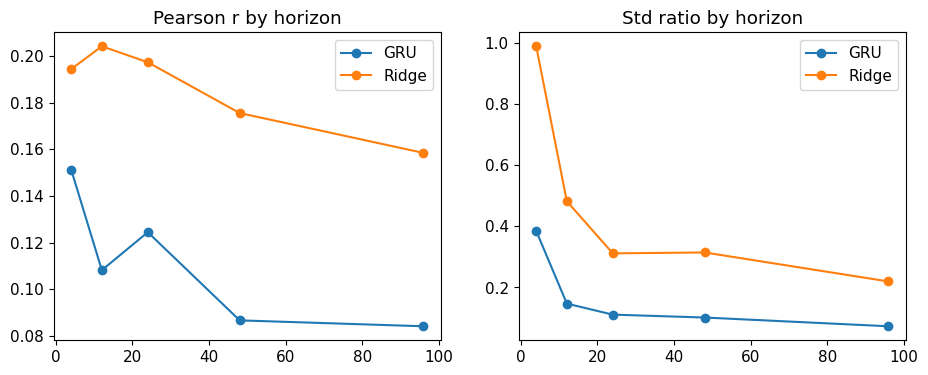

In [16]:
hz_parts = []
for cid in container_ids:
    tt = triplets[cid]
    h = horizon_comparison(tt['actual'], tt['gru'], tt['ridge'])
    h['container_id'] = cid
    hz_parts.append(h)
hz_cohort = pd.concat(hz_parts).groupby('horizon').mean(numeric_only=True)
display(hz_cohort)

fig, ax = plt.subplots(1, 2, figsize=(11,4))
ax[0].plot(hz_cohort.index, hz_cohort['gru_r'], marker='o', label='GRU')
ax[0].plot(hz_cohort.index, hz_cohort['ridge_r'], marker='o', label='Ridge')
ax[0].set_title('Pearson r by horizon'); ax[0].legend()
ax[1].plot(hz_cohort.index, hz_cohort['gru_std_ratio'], marker='o', label='GRU')
ax[1].plot(hz_cohort.index, hz_cohort['ridge_std_ratio'], marker='o', label='Ridge')
ax[1].set_title('Std ratio by horizon'); ax[1].legend()
plt.show()


## 13. Analysis 8 — Container ranking


,container_id,gru_r,ridge_r,delta_r,alpha
80,c_15179,0.461857,0.600590,0.138733,1.0
34,c_12517,0.334154,0.572216,0.238062,1.0
23,c_1186,0.517157,0.548733,0.031575,1.0
26,c_12158,-0.233604,0.546719,0.780323,1.0
71,c_14471,0.032160,0.509564,0.477404,1.0
72,c_14820,0.159154,0.479614,0.320461,1.0
42,c_12999,0.272995,0.437391,0.164396,1.0
84,c_15446,0.051806,0.432588,0.380782,0.0
98,c_16048,0.092549,0.426001,0.333452,1.0
24,c_11996,0.456871,0.425369,-0.031502,1.0


,container_id,gru_r,ridge_r,delta_r,alpha
31,c_12231,-0.357115,-0.532815,-0.175700,1.0
76,c_14964,-0.355937,-0.074375,0.281563,1.0
77,c_15030,-0.324158,0.124680,0.448838,1.0
61,c_14106,-0.244475,0.009304,0.253779,0.0
47,c_13170,-0.240426,0.338990,0.579416,1.0
3,c_10132,-0.236502,0.124555,0.361057,1.0
26,c_12158,-0.233604,0.546719,0.780323,1.0
0,c_10032,-0.190530,0.046238,0.236768,1.0
21,c_11752,-0.184582,-0.082272,0.102310,1.0
50,c_13308,-0.181373,0.117154,0.298527,0.0


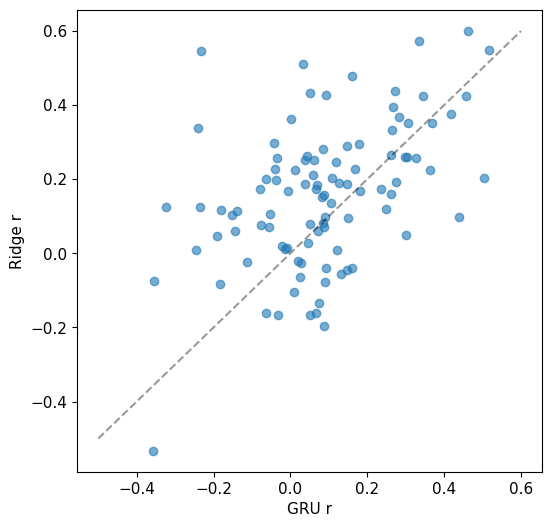

In [17]:
rank_df = stats_df.merge(alpha, on='container_id', how='left')
rank_df['delta_r'] = rank_df['ridge_r'] - rank_df['gru_r']
display(rank_df.nlargest(10, 'ridge_r')[['container_id','gru_r','ridge_r','delta_r','alpha']])
display(rank_df.nsmallest(10, 'gru_r')[['container_id','gru_r','ridge_r','delta_r','alpha']])
fig, ax = plt.subplots(figsize=(6,6))
ax.scatter(rank_df['gru_r'], rank_df['ridge_r'], alpha=0.6)
lims = [-0.5, 0.6]
ax.plot(lims, lims, 'k--', alpha=0.4)
ax.set_xlabel('GRU r'); ax.set_ylabel('Ridge r'); plt.show()


## 14. Analysis 9 — Generator property correlations


In [18]:
cols = [c for c in ['alpha','kappa_effective','delta_r','actual_std','gru_std','ridge_std'] if c in rank_df.columns]
display(rank_df[cols].corr(numeric_only=True))


,alpha,kappa_effective,delta_r,actual_std,gru_std,ridge_std
alpha,1.000000,1.000000,-0.114239,-0.134627,0.091621,-0.089406
kappa_effective,1.000000,1.000000,-0.114239,-0.134627,0.091621,-0.089406
delta_r,-0.114239,-0.114239,1.000000,-0.217005,-0.137599,-0.149282
actual_std,-0.134627,-0.134627,-0.217005,1.000000,0.396155,0.464373
gru_std,0.091621,0.091621,-0.137599,0.396155,1.000000,0.676499
ridge_std,-0.089406,-0.089406,-0.149282,0.464373,0.676499,1.000000


## 15. Analysis 10 — Evidence synthesis


In [19]:
synthesis = {
    'mean_gru_r': float(rank_df.gru_r.mean()),
    'mean_ridge_r': float(rank_df.ridge_r.mean()),
    'fraction_ridge_beats_gru': float((rank_df.delta_r > 0).mean()),
    'mean_gru_std_ratio': float((rank_df.gru_std/rank_df.actual_std).mean()),
    'mean_ridge_std_ratio': float((rank_df.ridge_std/rank_df.actual_std).mean()),
    'b0_ar1_r2_pooled': lin.get('ar1_r2'),
    'b0_ar2_r2_pooled': lin.get('ar2_r2'),
    'b0_acf_lags_1_10_mean_abs': acf_out.get('acf_lags_1_10_mean_abs'),
}
print(json.dumps(synthesis, indent=2))


{
  "mean_gru_r": 0.08413424568987238,
  "mean_ridge_r": 0.15847824059072665,
  "fraction_ridge_beats_gru": 0.6262626262626263,
  "mean_gru_std_ratio": 0.07300256933212737,
  "mean_ridge_std_ratio": 0.21958113841514448,
  "b0_ar1_r2_pooled": 0.20145034135286366,
  "b0_ar2_r2_pooled": 0.213307478906688,
  "b0_acf_lags_1_10_mean_abs": 0.2586125268960964
}


## 16. Final findings

Quantitative synthesis is written to `experiments/csrle_ridge_vs_gru_analysis_2026-07-26_013200/results/evidence_synthesis.json` when `run_analysis.py` is executed.

Thesis-ready narrative: `docs/csrle_ridge_vs_gru_analysis/summary.md`.
